In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import requests
import random
import os

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version : {torch.__version__}')
print(f'Device          : {device}')


# ============================================================
# Comments / Explanation
# ============================================================

# torch.manual_seed(42)
# ---------------------
# Sets the random seed for PyTorch. This ensures that random
# operations (such as weight initialization or random tensors)
# produce the same results every time the program is executed.

# np.random.seed(42)
# ------------------
# Sets the random seed for NumPy. Any random arrays generated
# using NumPy will be identical across different runs.

# random.seed(42)
# ---------------
# Sets the random seed for Python's built-in random module,
# making functions like random.randint() and random.choice()
# reproducible.

# Why use 42?
# -----------
# The value 42 is simply a commonly used seed in programming.
# It has no special meaning—any integer can be used. The goal
# is to ensure that experiments can be reproduced consistently.

# device = torch.device(...)
# --------------------------
# Checks whether a CUDA-compatible NVIDIA GPU is available.
#
# If a GPU is available:
#     device = 'cuda'
#     -> Training and computations will run on the GPU,
#        making deep learning much faster.
#
# Otherwise:
#     device = 'cpu'
#     -> Training and computations will run on the CPU.

# torch.cuda.is_available()
# -------------------------
# Returns True if PyTorch detects a CUDA-enabled GPU,
# otherwise returns False.

# Printing PyTorch version and device
# -----------------------------------
# Displays the installed PyTorch version and the hardware
# (CPU or GPU) that will be used for computations.

PyTorch version : 2.11.0+cu128
Device          : cuda


In [2]:
url  = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
text = requests.get(url).text

print(f'Total characters : {len(text):,}')
print(f'Total lines      : {text.count(chr(10)):,}')
print(f'\n--- First 500 characters ---')
print(text[:500])

Total characters : 1,115,394
Total lines      : 40,000

--- First 500 characters ---
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


In [3]:
vocab      = sorted(set(text))
vocab_size = len(vocab)

char2idx = {ch: idx for idx, ch in enumerate(vocab)}
idx2char = {idx: ch  for idx, ch in enumerate(vocab)}

print(f'Vocabulary size : {vocab_size} unique characters')
print(f'\nVocabulary:')
print(''.join(vocab))

print(f'\nSample mappings:')
for ch in ['A', 'a', ' ', '\n', 'z']:
    if ch in char2idx:
        printable = repr(ch)
        print(f'  {printable:<6} → {char2idx[ch]}')

encoded = np.array([char2idx[ch] for ch in text], dtype=np.int64)
print(f'\nEncoded shape   : {encoded.shape}')
print(f'First 20 values : {encoded[:20]}')
print(f'Decoded back    : {"".join(idx2char[i] for i in encoded[:20])}')


# ============================================================
# Comments / Explanation
# ============================================================

# set(text)
# ---------
# A set stores only unique values.
# Converting the text into a set removes all duplicate characters,
# leaving only the distinct characters that appear in the dataset.
#
# Example:
#     text = "banana"
#     set(text) --> {'b', 'a', 'n'}

# sorted(set(text))
# -----------------
# Converts the set into a sorted list.
# Sorting ensures that the vocabulary has a fixed and consistent
# ordering every time the program is executed.
#
# Example:
#     {'b', 'a', 'n'} --> ['a', 'b', 'n']

# vocab
# -----
# A list containing every unique character in the dataset.
#
# It may include:
# - Uppercase letters
# - Lowercase letters
# - Digits
# - Spaces
# - Punctuation
# - Newline characters

# len(vocab)
# ----------
# Returns the total number of unique characters.
# This is known as the vocabulary size.

# char2idx
# --------
# Creates a dictionary that maps each character to a unique integer.
#
# Example:
#     {
#         'A': 12,
#         'B': 13,
#         'a': 38,
#         ' ': 0
#     }
#
# This mapping allows the neural network to work with numbers
# instead of raw text.

# Dictionary Comprehension
# ------------------------
# Syntax:
#     {key : value for item in iterable}
#
# It is a concise way to create dictionaries.

# enumerate(vocab)
# ----------------
# enumerate() returns both:
# - index
# - value
#
# Example:
#     vocab = ['a', 'b', 'c']
#
#     enumerate(vocab)
#
#     Output:
#     (0, 'a')
#     (1, 'b')
#     (2, 'c')
#
# Here:
#     idx = numerical index
#     ch  = character

# idx2char
# --------
# Creates the reverse mapping.
#
# Instead of:
#     Character → Number
#
# It maps:
#     Number → Character
#
# Example:
#     {
#         12: 'A',
#         13: 'B',
#         38: 'a'
#     }
#
# This dictionary is useful when converting model predictions
# back into readable text.

# Printing the vocabulary
# -----------------------
# Displays:
# - Total number of unique characters.
# - Every unique character found in the dataset.

# ''.join(vocab)
# --------------
# Combines all characters in the vocabulary list into one string.
#
# Example:
#     ['H','e','l','l','o']
#     -->
#     "Hello"
#
# The empty string ('') means no separator is inserted between characters.

# Sample mappings
# ---------------
# Checks a few selected characters and prints their corresponding
# integer IDs from the char2idx dictionary.

# repr(ch)
# --------
# Returns the printable representation of an object.
#
# It is especially useful for invisible characters.
#
# Example:
#     ' '   --> "' '"
#     '\n'  --> "'\\n'"
#
# Without repr(), newline characters would actually create
# a new line when printed.

# if ch in char2idx
# -----------------
# Ensures that the character exists in the vocabulary before
# trying to access its index.
# This prevents a KeyError.

# encoded
# -------
# Converts the entire text into a sequence of integers.
#
# Every character is replaced by its corresponding index.
#
# Example:
#     Text:
#         "CAT"
#
#     Mapping:
#         C → 10
#         A → 5
#         T → 20
#
#     Encoded:
#         [10, 5, 20]

# List Comprehension
# ------------------
# Syntax:
#     [expression for item in iterable]
#
# Here:
#     [char2idx[ch] for ch in text]
#
# loops through every character in the dataset and replaces
# it with its corresponding integer ID.

# np.array(..., dtype=np.int64)
# -----------------------------
# Converts the list of integers into a NumPy array.
#
# dtype=np.int64 specifies that every value should be stored
# as a 64-bit integer.
#
# Integer encoding is required because neural networks cannot
# process raw text directly.

# encoded.shape
# -------------
# Returns the dimensions of the NumPy array.
#
# Since encoded is a 1D array, the shape will be:
#     (number_of_characters,)

# encoded[:20]
# ------------
# Displays the first 20 encoded integer values.
#
# This helps verify that the encoding process worked correctly.

# "".join(idx2char[i] for i in encoded[:20])
# ------------------------------------------
# Decodes the first 20 integers back into characters.
#
# Steps:
# 1. Take each integer from encoded[:20].
# 2. Look up the corresponding character using idx2char.
# 3. Join all characters together into one string.
#
# This confirms that:
#
#     Original Text
#          ↓
#     Integer Encoding
#          ↓
#     Character Decoding
#
# reproduces the original text correctly.

# Why encode text?
# ----------------
# Neural networks cannot understand characters or words directly.
# They only perform mathematical operations on numbers.
#
# Therefore, every character must first be converted into an
# integer before it can be used for training.
#
# Likewise, after the model generates predictions (integers),
# they must be converted back into characters so humans can
# read the generated text.
# ============================================================

Vocabulary size : 65 unique characters

Vocabulary:

 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz

Sample mappings:
  'A'    → 13
  'a'    → 39
  ' '    → 1
  '\n'   → 0
  'z'    → 64

Encoded shape   : (1115394,)
First 20 values : [18 47 56 57 58  1 15 47 58 47 64 43 52 10  0 14 43 44 53 56]
Decoded back    : First Citizen:
Befor


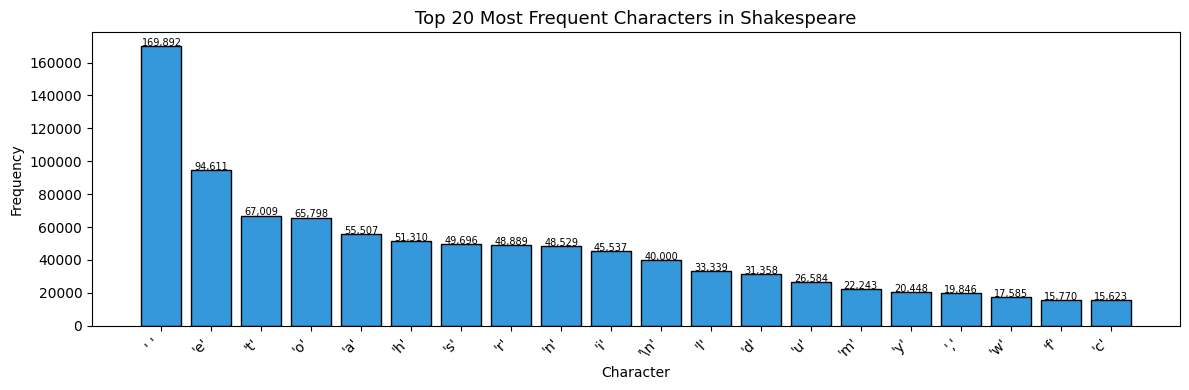

Space is the most common character — text is mostly words with spaces.
Newline ('\n') frequency : 40,000


In [4]:
from collections import Counter

char_counts = Counter(text)

top_chars  = char_counts.most_common(20)
chars, cnts = zip(*top_chars)

plt.figure(figsize=(12, 4))
bars = plt.bar(range(len(chars)),
               cnts,
               color='#3498db',
               edgecolor='black')
plt.xticks(range(len(chars)),
           [repr(c) for c in chars],
           rotation=45, ha='right')
plt.title('Top 20 Most Frequent Characters in Shakespeare', fontsize=13)
plt.ylabel('Frequency')
plt.xlabel('Character')
for bar, cnt in zip(bars, cnts):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 200,
             f'{cnt:,}', ha='center', fontsize=7)
plt.tight_layout()
plt.show()

print(f"Space is the most common character — text is mostly words with spaces.")
print(f"Newline ('\\n') frequency : {char_counts[chr(10)]:,}")


# ============================================================
# Comments / Explanation
# ============================================================

# from collections import Counter
# -------------------------------
# Imports the Counter class from Python's built-in collections module.
#
# Counter is a specialized dictionary that automatically counts
# how many times each element appears in an iterable.
#
# Example:
#     text = "banana"
#     Counter(text)
#
# Output:
#     {'a': 3, 'n': 2, 'b': 1}

# char_counts = Counter(text)
# ---------------------------
# Counts the frequency of every character in the Shakespeare dataset.
#
# The result is similar to:
#
# {
#     ' ': 169892,
#     'e': 94562,
#     't': 67009,
#     '\n': 40000,
#     ...
# }
#
# Each key is a character, and its value is the number of
# times that character appears in the dataset.

# char_counts.most_common(20)
# ---------------------------
# Returns a list containing the 20 most frequently occurring
# characters, sorted from highest frequency to lowest.
#
# Example:
# [
#     (' ', 169892),
#     ('e', 94562),
#     ('t', 67009),
#     ...
# ]

# top_chars
# ---------
# Stores the top 20 (character, frequency) pairs returned
# by the Counter object.

# zip(*top_chars)
# ---------------
# Separates the list of tuples into two separate sequences.
#
# Suppose:
#
# top_chars =
# [
#     ('a', 10),
#     ('b', 7),
#     ('c', 4)
# ]
#
# Then:
#
# chars = ('a', 'b', 'c')
# cnts  = (10, 7, 4)
#
# The '*' operator unpacks the list before passing it to zip().

# plt.figure(figsize=(12, 4))
# ---------------------------
# Creates a new plotting area.
#
# figsize=(12,4)
# means:
# - Width  = 12 inches
# - Height = 4 inches
#
# This creates a wide graph so that character labels are
# easier to read.

# plt.bar(...)
# ------------
# Creates a vertical bar chart.
#
# range(len(chars))
# -----------------
# Generates x-axis positions:
#
# If there are 20 characters:
#
# range(20)
#
# produces:
#
# 0, 1, 2, ..., 19
#
# These numbers determine where each bar will be placed.

# cnts
# ----
# Specifies the height of each bar.
#
# Higher frequency → Taller bar.

# color='#3498db'
# ---------------
# Sets the fill color of the bars.
#
# '#3498db' is a hexadecimal color code representing a shade
# of blue.

# edgecolor='black'
# -----------------
# Draws a black border around each bar, making them easier
# to distinguish.

# bars
# ----
# Stores the bar objects returned by plt.bar().
#
# These objects are later used to place the frequency labels
# above each bar.

# plt.xticks(...)
# ---------------
# Customizes the x-axis labels.

# range(len(chars))
# -----------------
# Specifies the positions of the labels.

# [repr(c) for c in chars]
# ------------------------
# Converts each character into a printable representation.
#
# Examples:
#
# ' '   --> "' '"
# '\n'  --> "'\\n'"
#
# This makes invisible characters visible on the graph.

# rotation=45
# -----------
# Rotates x-axis labels by 45 degrees to prevent overlapping.

# ha='right'
# ----------
# Aligns each rotated label to the right for better readability.

# plt.title(...)
# --------------
# Adds a title to the graph.
#
# fontsize=13
# sets the font size.

# plt.ylabel(...)
# ---------------
# Labels the y-axis.
#
# The y-axis represents character frequency.

# plt.xlabel(...)
# ---------------
# Labels the x-axis.
#
# The x-axis represents the characters.

# for bar, cnt in zip(bars, cnts)
# -------------------------------
# Iterates through every bar and its corresponding frequency.
#
# zip() pairs together:
#
# bar object ↔ frequency

# plt.text(...)
# -------------
# Places text above each bar.

# bar.get_x()
# -----------
# Returns the x-coordinate of the left side of the bar.

# bar.get_width()
# ---------------
# Returns the width of the bar.

# bar.get_x() + bar.get_width()/2
# -------------------------------
# Calculates the center of the bar so the text appears
# perfectly centered.

# bar.get_height()
# ----------------
# Returns the height of the current bar.

# + 200
# -----
# Moves the text slightly above the top of the bar so it
# doesn't overlap with the bar itself.

# f'{cnt:,}'
# ----------
# Displays the frequency with commas.
#
# Example:
# 125000
#
# becomes
#
# 125,000

# ha='center'
# -----------
# Centers the text horizontally.

# fontsize=7
# -----------
# Sets a small font size so all labels fit.

# plt.tight_layout()
# ------------------
# Automatically adjusts spacing between graph elements.
#
# Prevents labels, titles, and ticks from being cut off.

# plt.show()
# ----------
# Displays the completed graph.

# char_counts[chr(10)]
# --------------------
# Retrieves the frequency of the newline character.
#
# chr(10) represents '\n'.
#
# This is equivalent to:
#
# char_counts['\n']

# Why analyze character frequencies?
# ----------------------------------
# Character frequency analysis helps us understand the dataset.
#
# It tells us:
# - Which characters appear most often.
# - Whether spaces dominate the text.
# - How common punctuation is.
# - How frequently new lines occur.
#
# This information is useful when building a character-level
# language model because the model learns probability
# distributions over these characters.

# Why use a bar chart?
# --------------------
# A bar chart provides an easy visual comparison of character
# frequencies.
#
# Taller bars indicate more frequently occurring characters,
# making patterns in the dataset immediately visible.
# ============================================================

In [5]:
SEQ_LENGTH = 100
BATCH_SIZE  = 64

def get_batch(encoded, seq_length, batch_size):
    max_start = len(encoded) - seq_length - 1
    starts    = np.random.randint(0, max_start, size=batch_size)

    x_batch = np.array([encoded[i : i+seq_length]     for i in starts])
    y_batch = np.array([encoded[i+1 : i+seq_length+1] for i in starts])

    x_tensor = torch.tensor(x_batch, dtype=torch.long)
    y_tensor = torch.tensor(y_batch, dtype=torch.long)

    return x_tensor, y_tensor


x_test, y_test = get_batch(encoded, SEQ_LENGTH, BATCH_SIZE)
print(f'Input  batch shape : {x_test.shape}   (batch_size × seq_length)')
print(f'Target batch shape : {y_test.shape}')
print(f'\nInput  (first 50 chars) : {"".join(idx2char[i.item()] for i in x_test[0][:50])}')
print(f'Target (first 50 chars) : {"".join(idx2char[i.item()] for i in y_test[0][:50])}')
print(f'\nNotice: target is input shifted by one character to the right.')


# ============================================================
# Comments / Explanation
# ============================================================

# SEQ_LENGTH = 100
# ----------------
# Defines the length of each training sequence.
#
# Each input sample given to the neural network will contain
# exactly 100 consecutive characters.

# BATCH_SIZE = 64
# ---------------
# Specifies how many sequences will be processed together
# during one training iteration.
#
# Here, each batch contains 64 sequences.

# def get_batch(...)
# -----------------
# Defines a function that randomly creates one training batch.
#
# Inputs:
# - encoded      : Entire dataset encoded as integers.
# - seq_length   : Number of characters per sequence.
# - batch_size   : Number of sequences to generate.
#
# Output:
# - x_tensor : Input sequences.
# - y_tensor : Target sequences (shifted by one character).

# max_start = len(encoded) - seq_length - 1
# -----------------------------------------
# Computes the largest valid starting position for a sequence.
#
# We subtract:
# - seq_length -> because we need enough characters to form
#                 the input sequence.
# - 1          -> because the target sequence is shifted by
#                 one character.
#
# This prevents indexing beyond the end of the dataset.

# np.random.randint(...)
# ----------------------
# Randomly selects 'batch_size' starting positions.
#
# Parameters:
# - 0         -> minimum starting index.
# - max_start -> maximum valid starting index.
# - size      -> number of random indices to generate.
#
# Every sequence in the batch begins at one of these
# randomly selected positions.

# List Comprehension
# ------------------
# A concise way to create lists using a loop.
#
# General syntax:
#
# [expression for item in iterable]

# x_batch = np.array(...)
# -----------------------
# Creates the input sequences.
#
# For every random starting position 'i':
#
# encoded[i : i + seq_length]
#
# extracts exactly 100 consecutive characters.
#
# Example:
#
# Dataset:
#
# A B C D E F G H I ...
#
# If:
# i = 2
#
# x_batch becomes:
#
# C D E F G ...

# y_batch = np.array(...)
# -----------------------
# Creates the target sequences.
#
# Instead of starting at i,
# it starts at i + 1.
#
# encoded[i+1 : i+seq_length+1]
#
# This shifts every sequence one character to the left.
#
# Example:
#
# Input :
# H e l l o
#
# Target:
# e l l o _
#
# The model learns:
#
# "Given these characters,
#  predict the next character."

# Why shift by one character?
# ---------------------------
# Character-level language models learn the probability of
# the next character.
#
# Input :
# T h e
#
# Target:
# h e _
#
# During training, the model tries to predict each next
# character in the sequence.

# torch.tensor(...)
# -----------------
# Converts the NumPy arrays into PyTorch tensors.
#
# Neural networks in PyTorch operate on tensors rather than
# NumPy arrays.

# dtype=torch.long
# ----------------
# Stores the values as 64-bit integers.
#
# Character indices must be integers because they will later
# be passed into an Embedding layer.
#
# Embedding layers require integer indices, not floating-point
# numbers.

# x_tensor
# --------
# Contains the input sequences.
#
# Shape:
#
# (batch_size, seq_length)
#
# Here:
#
# (64, 100)

# y_tensor
# --------
# Contains the corresponding target sequences.
#
# It has exactly the same shape as x_tensor.

# return x_tensor, y_tensor
# -------------------------
# Returns both tensors so they can be used for training.

# x_test, y_test = get_batch(...)
# -------------------------------
# Calls the function once to generate a sample training batch.
#
# This is useful for verifying that batching works correctly.

# Overall purpose of get_batch()
# ------------------------------
# Instead of training on the entire dataset at once,
# the dataset is divided into many small random batches.
#
# Benefits:
# - Faster training.
# - Lower memory usage.
# - Better generalization.
# - Random batches help the model learn more robust patterns.
# ============================================================

Input  batch shape : torch.Size([64, 100])   (batch_size × seq_length)
Target batch shape : torch.Size([64, 100])

Input  (first 50 chars) : ke against them.

MENENIUS:
Here come the clusters
Target (first 50 chars) : e against them.

MENENIUS:
Here come the clusters.

Notice: target is input shifted by one character to the right.


In [6]:
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers, dropout=0.3):
        super(CharLSTM, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.embedding = nn.Embedding(
            num_embeddings = vocab_size,
            embedding_dim  = embed_dim
        )

        self.lstm = nn.LSTM(
            input_size  = embed_dim,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        embedded     = self.embedding(x)
        out, hidden  = self.lstm(embedded, hidden)
        out          = self.dropout(out)
        logits       = self.fc(out)
        return logits, hidden

    def init_hidden(self, batch_size):
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        return (h0, c0)


EMBED_DIM   = 128
HIDDEN_SIZE = 512
NUM_LAYERS  = 2
DROPOUT     = 0.3

model = CharLSTM(
    vocab_size  = vocab_size,
    embed_dim   = EMBED_DIM,
    hidden_size = HIDDEN_SIZE,
    num_layers  = NUM_LAYERS,
    dropout     = DROPOUT
).to(device)

print(model)
print(f'\n--- Parameter Count ---')
for name, param in model.named_parameters():
    print(f'  {name:<35} {str(list(param.shape)):<25} {param.numel():>10,} params')
total = sum(p.numel() for p in model.parameters())
print(f'\n  Total : {total:,} trainable parameters')


# ============================================================
# Comments / Explanation
# ============================================================

# class CharLSTM(nn.Module)
# -------------------------
# Defines a custom neural network class named "CharLSTM".
#
# Every custom model in PyTorch inherits from nn.Module,
# which provides the functionality needed to build, train,
# save, and load neural networks.

# __init__()
# ----------
# The constructor of the class.
#
# It runs automatically when an object of CharLSTM is created.
#
# This is where all neural network layers are defined.

# super(CharLSTM, self).__init__()
# --------------------------------
# Calls the constructor of the parent class (nn.Module).
#
# This initializes important internal functionality provided
# by PyTorch, allowing the model to properly register layers
# and parameters.

# self.hidden_size
# ----------------
# Stores the number of hidden units in the LSTM.
#
# It is saved as a class variable so it can be accessed
# later in other methods (such as init_hidden()).

# self.num_layers
# ---------------
# Stores the number of stacked LSTM layers.

# nn.Embedding(...)
# ----------------
# Creates an Embedding Layer.
#
# Neural networks cannot directly learn from integer indices.
# The embedding layer converts each character index into a
# dense vector of real numbers.
#
# Example:
#
# Character Index:
#        15
#
# becomes
#
# [0.23, -1.45, 0.67, ..., 0.91]
#
# These vectors are learned during training.

# num_embeddings
# --------------
# Specifies how many unique tokens (characters) exist.
#
# This is simply the vocabulary size.

# embedding_dim
# -------------
# Specifies the length of each embedding vector.
#
# Here:
#
# Each character is represented using 128 numbers.

# nn.LSTM(...)
# ------------
# Creates the Long Short-Term Memory layer.
#
# LSTMs are a type of Recurrent Neural Network (RNN)
# designed to learn sequential data while remembering
# information over long time periods.

# input_size
# ----------
# Number of features entering the LSTM at each time step.
#
# Since the embedding outputs vectors of length 128,
# the LSTM receives 128 features.

# hidden_size
# -----------
# Number of neurons inside each LSTM layer.
#
# Larger values allow the model to learn more complex
# patterns but also increase memory usage and training time.

# num_layers
# ----------
# Number of stacked LSTM layers.
#
# Example:
#
# Layer 1
#    ↓
# Layer 2
#
# Stacking layers allows the network to learn more
# abstract sequential representations.

# batch_first=True
# ----------------
# Specifies the expected input shape.
#
# With batch_first=True:
#
# (Batch Size, Sequence Length, Features)
#
# Without it:
#
# (Sequence Length, Batch Size, Features)

# dropout
# -------
# Randomly disables a percentage of neurons during training.
#
# This helps reduce overfitting.
#
# Dropout is only applied when there is more than one
# LSTM layer.
#
# Therefore:
#
# dropout if num_layers > 1 else 0.0

# nn.Dropout(...)
# --------------
# Creates an additional dropout layer that is applied
# after the LSTM outputs.

# nn.Linear(...)
# -------------
# Fully Connected (Dense) Layer.
#
# It converts each hidden state produced by the LSTM into
# scores for every character in the vocabulary.
#
# Input:
# Hidden Size (512)
#
# Output:
# Vocabulary Size
#
# One score is produced for every possible next character.

# forward()
# ---------
# Defines how data flows through the neural network.
#
# During every forward pass, PyTorch automatically calls
# this method.

# x
# -
# Input tensor containing batches of encoded character indices.

# hidden=None
# -----------
# Represents the hidden state and cell state of the LSTM.
#
# If not supplied, PyTorch automatically initializes them
# to zeros.

# self.embedding(x)
# -----------------
# Converts integer character IDs into embedding vectors.
#
# Shape changes:
#
# Before:
# (Batch, Sequence Length)
#
# After:
# (Batch, Sequence Length, Embedding Dimension)

# self.lstm(...)
# -------------
# Processes the embedded sequence.
#
# Returns:
#
# out
# ----
# Hidden output for every time step.
#
# hidden
# ------
# Final hidden state and cell state.

# self.dropout(out)
# -----------------
# Applies dropout to the LSTM outputs during training.

# self.fc(out)
# ------------
# Converts each hidden vector into prediction scores
# (called logits) for every character.

# logits
# ------
# Raw prediction scores.
#
# They are NOT probabilities.
#
# During training,
# CrossEntropyLoss automatically applies Softmax internally.

# return logits, hidden
# ---------------------
# Returns:
#
# 1. Prediction scores.
# 2. Updated hidden state.

# init_hidden()
# -------------
# Creates the initial hidden state and cell state
# for the LSTM.

# torch.zeros(...)
# ---------------
# Creates tensors filled with zeros.
#
# Shape:
#
# (Number of Layers,
#  Batch Size,
#  Hidden Size)

# h0
# --
# Initial hidden state.

# c0
# --
# Initial cell state.
#
# LSTMs maintain both hidden state and cell state.

# .to(device)
# -----------
# Moves the tensors to the selected device
# (CPU or GPU).

# return (h0, c0)
# ---------------
# Returns both initial states as a tuple.

# ------------------------------------------------------------
# Model Hyperparameters
# ------------------------------------------------------------

# EMBED_DIM = 128
# ---------------
# Each character is represented by a vector containing
# 128 learned features.

# HIDDEN_SIZE = 512
# -----------------
# Number of neurons in each LSTM layer.

# NUM_LAYERS = 2
# --------------
# Uses two stacked LSTM layers.

# DROPOUT = 0.3
# -------------
# Randomly disables 30% of neurons during training
# to reduce overfitting.

# ------------------------------------------------------------
# Model Creation
# ------------------------------------------------------------

# model = CharLSTM(...)
# --------------------
# Creates an instance of the CharLSTM model using
# the specified hyperparameters.

# .to(device)
# -----------
# Moves the entire neural network to the selected
# device (CPU or GPU).

# model.named_parameters()
# ------------------------
# Returns every trainable parameter in the model,
# along with its corresponding name.
#
# This is useful for inspecting the architecture.

# param.shape
# -----------
# Returns the dimensions of the parameter tensor.

# param.numel()
# -------------
# Returns the total number of elements (parameters)
# inside the tensor.

# model.parameters()
# ------------------
# Returns all trainable parameters of the model.

# sum(p.numel() for p in model.parameters())
# ------------------------------------------
# Calculates the total number of trainable parameters
# in the neural network.

# Why use Embedding + LSTM + Linear?
# ----------------------------------
# The overall data flow is:
#
# Character Index
#        │
#        ▼
# Embedding Layer
#        │
#        ▼
# Dense Vector Representation
#        │
#        ▼
# LSTM Layers
#        │
#        ▼
# Hidden Features
#        │
#        ▼
# Linear Layer
#        │
#        ▼
# Prediction Scores (Logits)
#        │
#        ▼
# Predicted Next Character
#
# This architecture is commonly used for character-level
# language modeling because it learns both character
# representations and long-range dependencies in text.
# ============================================================

CharLSTM(
  (embedding): Embedding(65, 128)
  (lstm): LSTM(128, 512, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=512, out_features=65, bias=True)
)

--- Parameter Count ---
  embedding.weight                    [65, 128]                      8,320 params
  lstm.weight_ih_l0                   [2048, 128]                  262,144 params
  lstm.weight_hh_l0                   [2048, 512]                1,048,576 params
  lstm.bias_ih_l0                     [2048]                         2,048 params
  lstm.bias_hh_l0                     [2048]                         2,048 params
  lstm.weight_ih_l1                   [2048, 512]                1,048,576 params
  lstm.weight_hh_l1                   [2048, 512]                1,048,576 params
  lstm.bias_ih_l1                     [2048]                         2,048 params
  lstm.bias_hh_l1                     [2048]                         2,048 params
  fc.weight       

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=3e-3)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

def compute_loss(logits, targets):
    batch, seq, vocab = logits.shape
    logits_flat  = logits.reshape(batch * seq, vocab)
    targets_flat = targets.reshape(batch * seq)
    return criterion(logits_flat, targets_flat)


x_test, y_test = get_batch(encoded, SEQ_LENGTH, BATCH_SIZE)
x_test         = x_test.to(device)
y_test         = y_test.to(device)

with torch.no_grad():
    logits, _ = model(x_test)
    test_loss = compute_loss(logits, y_test)

print(f'Untrained model loss     : {test_loss.item():.4f}')
print(f'Expected (random) loss   : {np.log(vocab_size):.4f}  (= log(vocab_size))')
print(f'\nPerplexity (untrained)   : {np.exp(test_loss.item()):.1f}')
print(f'Perplexity = {vocab_size} means the model is as confused as random guessing.')
print(f'Good trained models get perplexity < 10 on this dataset.')


# ============================================================
# Comments / Explanation
# ============================================================

# nn.CrossEntropyLoss()
# ---------------------
# Creates the loss function used for multi-class classification.
#
# In character-level language modeling, the model predicts
# one character out of the entire vocabulary.
#
# CrossEntropyLoss compares:
#
# Predicted Scores (Logits)
#            vs
# Correct Character Index
#
# and computes how wrong the prediction is.
#
# Smaller loss  -> Better predictions.
# Larger loss   -> Poor predictions.

# criterion
# ---------
# Stores the loss function so it can be reused during training.

# optim.Adam(...)
# ---------------
# Creates the Adam optimizer.
#
# The optimizer is responsible for updating the neural network's
# weights after every training iteration.
#
# Adam is one of the most commonly used optimization algorithms
# because it converges quickly and adapts the learning rate
# automatically for each parameter.

# model.parameters()
# ------------------
# Returns all trainable parameters (weights and biases)
# of the neural network.
#
# These are the values that Adam will update during training.

# lr = 3e-3
# ---------
# Specifies the learning rate.
#
# 3e-3 means:
#
# 3 × 10^-3 = 0.003
#
# The learning rate controls how much the weights change
# after each optimization step.
#
# Large learning rate:
# - Faster learning.
# - Risk of overshooting the optimum.
#
# Small learning rate:
# - More stable.
# - Slower training.

# optim.lr_scheduler.ReduceLROnPlateau(...)
# -----------------------------------------
# Creates a Learning Rate Scheduler.
#
# Instead of keeping the learning rate fixed,
# this scheduler automatically reduces it when
# training stops improving.

# mode='min'
# ----------
# Indicates that lower values are better.
#
# Since we monitor the loss,
# we want it to decrease.

# factor=0.5
# ----------
# When triggered,
# the learning rate is multiplied by 0.5.
#
# Example:
#
# 0.003
#   ↓
# 0.0015

# patience=3
# ----------
# Waits for 3 consecutive epochs without improvement
# before reducing the learning rate.

# Why use a learning rate scheduler?
# ----------------------------------
# Early in training,
# larger learning rates help the model learn quickly.
#
# Later,
# smaller learning rates allow the model to make
# finer adjustments and converge more smoothly.

# ------------------------------------------------------------
# compute_loss()
# ------------------------------------------------------------

# This function computes the Cross Entropy Loss between
# the predicted logits and the target character indices.

# logits.shape
# ------------
# The model outputs logits with shape:
#
# (Batch Size,
#  Sequence Length,
#  Vocabulary Size)

# batch
# -----
# Number of sequences in one batch.

# seq
# ---
# Number of characters in each sequence.

# vocab
# -----
# Total number of unique characters.

# logits.reshape(batch * seq, vocab)
# ----------------------------------
# Flattens the predictions.
#
# Original shape:
#
# (64, 100, 65)
#
# becomes
#
# (6400, 65)
#
# Every character prediction becomes an independent
# training example.

# Why flatten?
# ------------
# CrossEntropyLoss expects inputs shaped as:
#
# (Number of Samples,
#  Number of Classes)
#
# Instead of:
#
# (Batch,
#  Sequence,
#  Classes)

# targets.reshape(batch * seq)
# ----------------------------
# Flattens the target tensor.
#
# Original:
#
# (64, 100)
#
# becomes
#
# (6400,)
#
# Every target character now corresponds to one row
# in logits_flat.

# criterion(logits_flat, targets_flat)
# ------------------------------------
# Computes the average Cross Entropy Loss across
# every character prediction in the batch.

# return criterion(...)
# ---------------------
# Returns a single scalar loss value.

# ------------------------------------------------------------
# Preparing a Test Batch
# ------------------------------------------------------------

# get_batch(...)
# --------------
# Generates one random batch of input and target sequences
# from the encoded dataset.

# .to(device)
# -----------
# Moves the tensors to the selected device
# (CPU or GPU).

# ------------------------------------------------------------
# with torch.no_grad()
# ------------------------------------------------------------

# Temporarily disables gradient computation.
#
# This is useful during evaluation because:
#
# - Faster execution.
# - Lower memory usage.
# - No gradients are stored.

# model(x_test)
# -------------
# Performs a forward pass through the neural network.
#
# Outputs:
#
# logits
# -------
# Prediction scores for every character.
#
# _
# -
# Represents the hidden state.
#
# It is ignored because it is not needed here.

# compute_loss(...)
# ----------------
# Calculates the prediction error for the untrained model.

# test_loss
# ---------
# A single number representing how well (or poorly)
# the untrained model predicts the next character.

# test_loss.item()
# ----------------
# Extracts the Python float value from the PyTorch tensor.

# np.log(vocab_size)
# ------------------
# Computes the natural logarithm of the vocabulary size.
#
# Why?
#
# If the model guesses completely at random,
# every character has probability:
#
# 1 / Vocabulary Size
#
# The expected Cross Entropy Loss for random guessing is:
#
# log(Vocabulary Size)
#
# Therefore,
# comparing the actual loss with log(vocab_size)
# tells us whether the model is performing better
# than random guessing.

# np.exp(test_loss.item())
# ------------------------
# Converts Cross Entropy Loss into Perplexity.
#
# Formula:
#
# Perplexity = e^(Loss)
#
# Lower perplexity indicates better language modeling.

# What is Perplexity?
# -------------------
# Perplexity measures how "confused" the model is
# when predicting the next character.
#
# Lower is better.
#
# Example:
#
# Perplexity = 65
# -> The model is as confused as randomly choosing
#    among 65 possible characters.
#
# Perplexity = 5
# -> The model effectively narrows the prediction
#    down to about 5 likely characters.

# Overall Workflow
# ----------------
# Input Sequences
#        │
#        ▼
# Neural Network
#        │
#        ▼
# Logits (Prediction Scores)
#        │
#        ▼
# Flatten Predictions
#        │
#        ▼
# CrossEntropyLoss
#        │
#        ▼
# Loss
#        │
#        ▼
# Perplexity
#
# This cell initializes all components needed for training
# (loss function, optimizer, scheduler) and evaluates how
# well the model performs before any learning has taken place.
# ============================================================

Untrained model loss     : 4.1707
Expected (random) loss   : 4.1744  (= log(vocab_size))

Perplexity (untrained)   : 64.8
Perplexity = 65 means the model is as confused as random guessing.
Good trained models get perplexity < 10 on this dataset.


In [9]:
NUM_ITERATIONS = 3000
LOG_EVERY      = 100
CHECKPOINT_DIR = './checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

train_losses = []
best_loss    = float('inf')

print(f'Training for {NUM_ITERATIONS} iterations...')
print(f'Device: {device}')
print(f'{"Iteration":>10}  {"Loss":>8}  {"Perplexity":>12}  {"LR":>12}')
print('-' * 50)

model.train()

for iteration in range(NUM_ITERATIONS):

    x_batch, y_batch = get_batch(encoded, SEQ_LENGTH, BATCH_SIZE)
    x_batch = x_batch.to(device)
    y_batch = y_batch.to(device)

    optimizer.zero_grad()
    logits, _ = model(x_batch)
    loss      = compute_loss(logits, y_batch)
    loss.backward()

    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    optimizer.step()

    train_losses.append(loss.item())

    if (iteration + 1) % LOG_EVERY == 0:
        avg_loss   = np.mean(train_losses[-LOG_EVERY:])
        perplexity = np.exp(avg_loss)
        current_lr = optimizer.param_groups[0]['lr']
        print(f'{iteration+1:>10}  {avg_loss:>8.4f}  {perplexity:>12.2f}  {current_lr:>12.6f}')
        scheduler.step(avg_loss)

        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(model.state_dict(),
                       os.path.join(CHECKPOINT_DIR, 'best_model.pt'))

print(f'\nTraining complete. Best loss: {best_loss:.4f}')


# ============================================================
# Comments / Explanation
# ============================================================

# NUM_ITERATIONS = 3000
# ---------------------
# Specifies the total number of training iterations.
#
# One iteration means:
# - Generate one batch.
# - Perform one forward pass.
# - Compute the loss.
# - Perform one backward pass.
# - Update the model weights.
#
# Here, the model will repeat this process 3000 times.

# LOG_EVERY = 100
# ---------------
# Determines how often training statistics are displayed.
#
# Every 100 iterations, the code prints:
# - Average Loss
# - Perplexity
# - Current Learning Rate

# CHECKPOINT_DIR
# --------------
# Specifies the folder where the trained model will be saved.

# os.makedirs(...)
# ----------------
# Creates the checkpoint directory if it does not already exist.
#
# exist_ok=True
# means no error will occur if the folder already exists.

# train_losses = []
# -----------------
# Creates an empty list that stores the loss value from
# every training iteration.
#
# This allows us to compute average losses later.

# best_loss = float('inf')
# ------------------------
# Initializes the best loss with positive infinity.
#
# float('inf') represents an infinitely large number.
#
# Since every real loss will be smaller than infinity,
# the first recorded loss automatically becomes
# the current best loss.

# model.train()
# -------------
# Puts the model into training mode.
#
# This enables layers such as:
# - Dropout
# - Batch Normalization (if present)
#
# to behave correctly during training.

# ------------------------------------------------------------
# Training Loop
# ------------------------------------------------------------

# for iteration in range(NUM_ITERATIONS)
# --------------------------------------
# Repeats the complete training process
# NUM_ITERATIONS times.

# get_batch(...)
# --------------
# Randomly selects one batch of input and target sequences
# from the encoded dataset.

# .to(device)
# -----------
# Moves both input and target tensors
# to the selected device (CPU or GPU).

# optimizer.zero_grad()
# ---------------------
# Clears all gradients stored from the previous iteration.
#
# PyTorch accumulates gradients by default.
# Therefore, gradients must be reset before each
# backward pass.

# model(x_batch)
# --------------
# Performs the forward pass.
#
# The input sequences pass through:
#
# Embedding
#     ↓
# LSTM
#     ↓
# Dropout
#     ↓
# Linear Layer
#
# producing prediction scores (logits).

# compute_loss(...)
# ----------------
# Computes the Cross Entropy Loss between
# the predicted logits and the target characters.

# loss.backward()
# ---------------
# Performs backpropagation.
#
# This computes the gradient of the loss
# with respect to every trainable parameter.
#
# These gradients tell the optimizer how
# each weight should change.

# torch.nn.utils.clip_grad_norm_(...)
# -----------------------------------
# Clips (limits) the gradients before updating the weights.
#
# max_norm = 1.0
#
# If the gradient norm becomes larger than 1,
# it is scaled down.
#
# This helps prevent the "Exploding Gradient Problem",
# which is common in recurrent neural networks like LSTMs.

# What are exploding gradients?
# -----------------------------
# During backpropagation, gradients can sometimes become
# extremely large.
#
# Consequences:
# - Unstable training.
# - Huge weight updates.
# - Loss becomes NaN.
# - Training may completely fail.
#
# Gradient clipping keeps training stable.

# optimizer.step()
# ----------------
# Updates the model's weights using the gradients
# computed during backpropagation.
#
# This is the actual learning step.

# loss.item()
# -----------
# Converts the loss tensor into a regular Python number.

# train_losses.append(...)
# ------------------------
# Stores the current iteration's loss so that
# training progress can be analyzed later.

# ------------------------------------------------------------
# Logging Training Progress
# ------------------------------------------------------------

# (iteration + 1) % LOG_EVERY == 0
# --------------------------------
# Executes the following block every 100 iterations.

# train_losses[-LOG_EVERY:]
# -------------------------
# Selects the most recent 100 loss values.
#
# Negative indexing starts counting from the end
# of the list.

# np.mean(...)
# ------------
# Computes the average loss over the last
# LOG_EVERY iterations.

# np.exp(avg_loss)
# ----------------
# Converts Cross Entropy Loss into Perplexity.
#
# Formula:
#
# Perplexity = e^(Loss)
#
# Lower perplexity indicates better predictions.

# optimizer.param_groups
# ----------------------
# Stores information about the optimizer's parameter groups.
#
# The learning rate is stored here.

# optimizer.param_groups[0]['lr']
# -------------------------------
# Retrieves the current learning rate being used
# by the optimizer.

# scheduler.step(avg_loss)
# ------------------------
# Updates the learning rate scheduler.
#
# The scheduler monitors the average loss.
#
# If the loss stops improving for several evaluations,
# it automatically reduces the learning rate.

# ------------------------------------------------------------
# Saving the Best Model
# ------------------------------------------------------------

# avg_loss < best_loss
# --------------------
# Checks whether the current model performs better
# than every previous version.

# best_loss = avg_loss
# --------------------
# Updates the best recorded loss.

# torch.save(...)
# ---------------
# Saves the model's learned parameters to disk.

# model.state_dict()
# ------------------
# Returns a dictionary containing all trainable
# weights and biases of the neural network.

# os.path.join(...)
# -----------------
# Creates an operating-system-independent file path.
#
# Example:
#
# './checkpoints'
# +
# 'best_model.pt'
#
# becomes
#
# './checkpoints/best_model.pt'

# Why save only the best model?
# -----------------------------
# During training, the model's performance may improve
# and later become worse due to overfitting.
#
# Saving only the best-performing model ensures that
# the final saved model is the most accurate one.

# Overall Training Workflow
# -------------------------
#
# Generate Batch
#       │
#       ▼
# Forward Pass
#       │
#       ▼
# Compute Loss
#       │
#       ▼
# Backpropagation
#       │
#       ▼
# Gradient Clipping
#       │
#       ▼
# Optimizer Updates Weights
#       │
#       ▼
# Store Loss
#       │
#       ▼
# Every 100 Iterations:
#     ├── Compute Average Loss
#     ├── Compute Perplexity
#     ├── Update Learning Rate Scheduler
#     └── Save Best Model
#
# This loop is the core of the learning process, where the
# neural network repeatedly improves its parameters by learning
# from batches of character sequences.
# ============================================================

Training for 3000 iterations...
Device: cuda
 Iteration      Loss    Perplexity            LR
--------------------------------------------------
       100    2.3084         10.06      0.003000
       200    1.6821          5.38      0.003000
       300    1.5339          4.64      0.003000
       400    1.4657          4.33      0.003000
       500    1.4262          4.16      0.003000
       600    1.3960          4.04      0.003000
       700    1.3706          3.94      0.003000
       800    1.3546          3.88      0.003000
       900    1.3354          3.80      0.003000
      1000    1.3257          3.76      0.003000
      1100    1.3104          3.71      0.003000
      1200    1.3068          3.69      0.003000
      1300    1.2934          3.65      0.003000
      1400    1.2852          3.62      0.003000
      1500    1.2821          3.60      0.003000
      1600    1.2767          3.58      0.003000
      1700    1.2721          3.57      0.003000
      1800    1.2647  

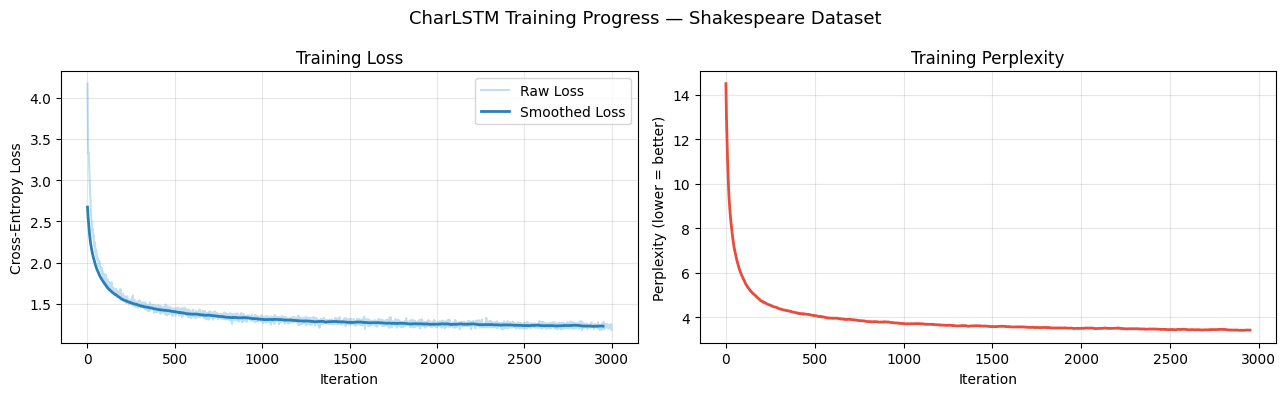

Starting perplexity : 64.8
Final   perplexity  : 3.4


In [10]:
def smooth(values, window=50):
    return np.convolve(values, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(train_losses, alpha=0.3, color='#3498db', label='Raw Loss')
axes[0].plot(smooth(train_losses), color='#2980b9', linewidth=2, label='Smoothed Loss')
axes[0].set_title('Training Loss', fontsize=12)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

perplexities = [np.exp(l) for l in smooth(train_losses)]
axes[1].plot(perplexities, color='#e74c3c', linewidth=2)
axes[1].set_title('Training Perplexity', fontsize=12)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Perplexity (lower = better)')
axes[1].grid(alpha=0.3)

plt.suptitle('CharLSTM Training Progress — Shakespeare Dataset', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Starting perplexity : {np.exp(train_losses[0]):.1f}')
print(f'Final   perplexity  : {np.exp(np.mean(train_losses[-100:])):.1f}')


# ============================================================
# Comments / Explanation
# ============================================================

# def smooth(values, window=50)
# -----------------------------
# Defines a helper function that smooths a sequence of values.
#
# During training, the loss fluctuates from one iteration
# to another because each batch is randomly sampled.
#
# Smoothing reduces these fluctuations, making the overall
# training trend easier to observe.

# values
# ------
# A list or NumPy array containing numerical values.
#
# In this case:
# values = train_losses

# window = 50
# -----------
# Specifies the size of the moving window.
#
# A window size of 50 means each smoothed value is computed
# using the average of 50 consecutive loss values.

# np.ones(window)
# ---------------
# Creates an array filled with ones.
#
# Example:
#
# window = 5
#
# Output:
#
# [1. 1. 1. 1. 1.]

# np.ones(window) / window
# ------------------------
# Divides every element by the window size.
#
# Example:
#
# window = 5
#
# Before:
#
# [1 1 1 1 1]
#
# After:
#
# [0.2 0.2 0.2 0.2 0.2]
#
# These values form an averaging filter.

# np.convolve(...)
# ---------------
# Performs the convolution operation.
#
# Here, convolution is used to compute a moving average.
#
# Instead of looking at one loss value,
# it averages several neighboring values,
# producing a smoother curve.

# mode='valid'
# ------------
# Returns only those averages where the entire window
# fits inside the input data.
#
# This avoids using incomplete windows at the beginning
# and end of the sequence.

# Why smooth the loss?
# --------------------
# Training loss often contains small random fluctuations.
#
# Smoothing helps reveal the true learning trend by reducing
# short-term noise while preserving long-term behavior.

# ------------------------------------------------------------
# Perplexity Calculation
# ------------------------------------------------------------

# perplexities = [np.exp(l) for l in smooth(train_losses)]
# --------------------------------------------------------
# Converts every smoothed loss value into its corresponding
# perplexity value.
#
# Formula:
#
# Perplexity = e^(Loss)
#
# Since Cross Entropy Loss is measured in logarithmic units,
# applying the exponential function converts it back into
# a more interpretable metric.

# List Comprehension
# ------------------
# Syntax:
#
# [expression for item in iterable]
#
# Here:
#
# For every smoothed loss value:
#
#     l
#
# compute:
#
#     np.exp(l)
#
# and store the results in a new list.

# np.exp(...)
# -----------
# Computes the exponential function.
#
# Example:
#
# np.exp(2)
#
# computes:
#
# e²

# train_losses[0]
# ---------------
# Retrieves the very first recorded training loss.
#
# This represents the model's performance before it has
# learned much from the data.

# train_losses[-100:]
# -------------------
# Selects the last 100 recorded training losses.
#
# Negative indexing starts counting from the end
# of the list.

# np.mean(...)
# ------------
# Computes the average of the last 100 losses.
#
# Averaging provides a more stable estimate than using
# only the final iteration's loss.

# Why compute the final perplexity using the average?
# ---------------------------------------------------
# Individual loss values may fluctuate because batches
# are selected randomly.
#
# Averaging the last 100 losses provides a more reliable
# estimate of the model's final performance.

# Overall Purpose of This Cell
# ----------------------------
# This cell summarizes the training progress by:
#
# 1. Smoothing the recorded loss values.
# 2. Converting loss into perplexity.
# 3. Displaying how the model improved from the beginning
#    to the end of training.
#
# Lower final loss and lower final perplexity indicate
# that the model has successfully learned patterns
# from the training data.
# ============================================================

In [11]:
def generate_text(model, start_string, length=500, temperature=1.0):
    model.eval()

    input_ids = torch.tensor(
        [[char2idx[ch] for ch in start_string if ch in char2idx]],
        dtype=torch.long
    ).to(device)

    hidden    = model.init_hidden(batch_size=1)
    generated = list(start_string)

    with torch.no_grad():
        if input_ids.shape[1] > 1:
            _, hidden = model(input_ids[:, :-1], hidden)

        current_input = input_ids[:, -1:]

        for _ in range(length):
            logits, hidden  = model(current_input, hidden)
            scaled_logits   = logits[0, -1, :] / temperature
            probabilities   = torch.softmax(scaled_logits, dim=0)
            next_char_idx   = torch.multinomial(probabilities, num_samples=1).item()
            next_char       = idx2char[next_char_idx]
            generated.append(next_char)
            current_input   = torch.tensor([[next_char_idx]],
                                           dtype=torch.long).to(device)

    return ''.join(generated)


model.load_state_dict(
    torch.load(os.path.join(CHECKPOINT_DIR, 'best_model.pt'),
               map_location=device)
)
print("Best model loaded.")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")


# ============================================================
# Comments / Explanation
# ============================================================

# def generate_text(...)
# ---------------------
# Defines a function that generates new text using the
# trained CharLSTM model.
#
# Inputs:
# - model         : The trained neural network.
# - start_string  : Initial text used to begin generation.
# - length        : Number of new characters to generate.
# - temperature   : Controls randomness in predictions.
#
# Output:
# - A generated text string.

# model.eval()
# ------------
# Switches the model into evaluation mode.
#
# This disables training-specific behavior such as Dropout,
# making predictions deterministic (except for sampling).

# torch.tensor(...)
# ----------------
# Converts the starting text into a PyTorch tensor.

# [char2idx[ch] for ch in start_string if ch in char2idx]
# -------------------------------------------------------
# Converts every character in the starting string into
# its corresponding integer index.
#
# The condition:
#
# if ch in char2idx
#
# ignores any character that is not present in the vocabulary.

# Why double square brackets [[...]] ?
# -----------------------------------
# A single sequence still needs a batch dimension.
#
# Without:
#
# [[...]]
#
# Shape:
#
# (Sequence Length)
#
# With:
#
# [[...]]
#
# Shape:
#
# (1, Sequence Length)
#
# Here,
# batch size = 1.

# dtype=torch.long
# ----------------
# Stores the character indices as integers.
#
# Embedding layers require integer inputs.

# .to(device)
# -----------
# Moves the tensor to the selected device
# (CPU or GPU).

# model.init_hidden(batch_size=1)
# -------------------------------
# Creates the initial hidden state and cell state
# for one sequence.

# generated = list(start_string)
# ------------------------------
# Converts the starting string into a list of characters.
#
# New predicted characters will be appended to this list.

# Why convert to a list?
# ----------------------
# Lists allow efficient appending.
#
# Strings are immutable in Python,
# meaning they cannot be modified directly.

# with torch.no_grad()
# --------------------
# Disables gradient computation.
#
# During text generation,
# gradients are unnecessary because the model
# is only making predictions.
#
# Benefits:
# - Faster execution.
# - Lower memory usage.

# input_ids.shape[1]
# ------------------
# Returns the sequence length.
#
# Shape:
#
# (Batch Size, Sequence Length)
#
# Index 1 refers to the sequence dimension.

# if input_ids.shape[1] > 1
# -------------------------
# Checks whether the starting string contains
# more than one character.
#
# If it does,
# the model processes all characters except
# the last one to build its hidden state.

# input_ids[:, :-1]
# -----------------
# Selects every character except the final one.
#
# :
# means every batch.
#
# :-1
# means from the beginning up to (but not including)
# the last character.

# Why exclude the last character?
# -------------------------------
# The last character will be used as the first
# prediction input.
#
# The earlier characters simply help establish
# the correct context.

# _, hidden = model(...)
# ----------------------
# Runs the initial context through the model.
#
# The logits are ignored because only the updated
# hidden state is needed.
#
# The underscore (_) is a Python convention for
# intentionally ignoring a returned value.

# current_input = input_ids[:, -1:]
# ---------------------------------
# Selects only the last character of the starting text.
#
# This character becomes the first input used
# for generation.
#
# Shape:
#
# (1,1)

# ------------------------------------------------------------
# Character Generation Loop
# ------------------------------------------------------------

# for _ in range(length)
# ----------------------
# Repeats the generation process for the desired number
# of new characters.
#
# The underscore (_) indicates that the loop variable
# itself is not needed.

# model(current_input, hidden)
# ----------------------------
# Predicts the next character using:
#
# - Current input character.
# - Previous hidden state.

# logits
# -------
# Raw prediction scores for every character
# in the vocabulary.

# hidden
# -------
# Updated hidden and cell states.
#
# These preserve the context accumulated so far.

# logits[0, -1, :]
# ----------------
# Selects the prediction scores for:
#
# Batch:
# 0
#
# Last time step:
# -1
#
# Every vocabulary score:
# :
#
# Result:
#
# One score for every possible next character.

# temperature
# -----------
# Controls the randomness of text generation.
#
# Lower temperature (<1):
# - More confident predictions.
# - More repetitive text.
#
# Higher temperature (>1):
# - More randomness.
# - More creative but less coherent text.
#
# temperature = 1
# means no scaling.

# scaled_logits = logits / temperature
# ------------------------------------
# Adjusts the prediction scores according to
# the selected temperature.

# torch.softmax(...)
# ------------------
# Converts logits into probabilities.
#
# After Softmax:
#
# - Every value is between 0 and 1.
# - All probabilities sum to 1.

# dim=0
# -----
# Applies Softmax across all vocabulary scores.

# torch.multinomial(...)
# ----------------------
# Randomly samples one character based on
# the predicted probability distribution.
#
# Higher probability characters are more
# likely to be selected.

# num_samples=1
# -------------
# Selects exactly one character.

# .item()
# -------
# Converts the resulting tensor into a
# regular Python integer.

# idx2char[next_char_idx]
# -----------------------
# Converts the predicted integer index
# back into its corresponding character.

# generated.append(...)
# ---------------------
# Adds the newly generated character
# to the growing output text.

# current_input = torch.tensor(...)
# --------------------------------
# Converts the predicted character index
# into a tensor.
#
# This newly generated character becomes
# the next input to the model.
#
# In this way, the model continuously
# feeds its own predictions back into itself.

# return ''.join(generated)
# -------------------------
# Combines all characters stored in the list
# into one complete string.
#
# This is the final generated text.

# ------------------------------------------------------------
# Loading the Best Trained Model
# ------------------------------------------------------------

# torch.load(...)
# ---------------
# Loads the saved model parameters from disk.

# os.path.join(...)
# -----------------
# Creates the file path in an operating-system-independent way.

# map_location=device
# -------------------
# Ensures the model is loaded onto the selected device.
#
# Example:
# - Saved on GPU → Loaded on CPU
# - Saved on CPU → Loaded on GPU

# model.load_state_dict(...)
# -------------------------
# Loads the saved weights into the current model.
#
# The model architecture must exactly match
# the architecture used during training.

# Overall Text Generation Process
# -------------------------------
#
# Starting Text
#       │
#       ▼
# Convert Characters → Integer IDs
#       │
#       ▼
# Embedding Layer
#       │
#       ▼
# LSTM
#       │
#       ▼
# Prediction Scores (Logits)
#       │
#       ▼
# Softmax
#       │
#       ▼
# Probability Distribution
#       │
#       ▼
# Random Sampling
#       │
#       ▼
# Next Character
#       │
#       ▼
# Feed Back Into Model
#       │
#       ▼
# Repeat Until Desired Length
#
# This feedback loop allows the model to generate text
# one character at a time while maintaining context from
# all previously generated characters.
# ============================================================

Best model loaded.
Parameters: 3,457,729


In [12]:
seed = "ROMEO:\nWhat light through yonder window breaks"

temperatures = [0.3, 0.7, 1.0, 1.3]

print("=" * 65)
print("GENERATING TEXT AT DIFFERENT TEMPERATURES")
print("=" * 65)

for temp in temperatures:
    print(f"\n--- Temperature = {temp} ", end="")
    if temp < 0.6:
        print("(Conservative — repetitive but structured) ---")
    elif temp < 0.9:
        print("(Balanced — best quality) ---")
    elif temp < 1.1:
        print("(Standard sampling) ---")
    else:
        print("(Creative — more surprising, may lose coherence) ---")

    generated = generate_text(model, seed, length=300, temperature=temp)
    print(generated)
    print()

print("=" * 65)
print("Observation: Lower temperature = more predictable, more repetitive.")
print("             Higher temperature = more diverse, less grammatical.")
print("             ~0.7 is usually the sweet spot for quality text.")


# ============================================================
# Comments / Explanation
# ============================================================

# seed
# ----
# The initial text (also called the prompt) used to start
# text generation.
#
# The model uses this text as context before predicting
# new characters.
#
# Different seed texts produce different generated outputs.

# temperatures
# ------------
# A list containing different temperature values that will
# be tested during text generation.
#
# Each value controls how random the predictions are.

# Temperature Values
# ------------------
# 0.3
# - Very conservative.
# - Almost always chooses high-probability characters.
# - Produces repetitive but grammatically consistent text.
#
# 0.7
# - Balanced randomness.
# - Often produces the most natural and readable text.
#
# 1.0
# - Standard sampling.
# - Uses the model's original probability distribution.
#
# 1.3
# - Highly creative.
# - More diverse word choices.
# - Greater chance of spelling mistakes or grammatical errors.

# print("=" * 65)
# ---------------
# Prints a separator line to improve readability
# of the generated output.

# for temp in temperatures
# ------------------------
# Iterates through every temperature value in the list.
#
# The model generates one sample for each temperature,
# allowing us to compare their effects.

# if / elif / else
# ----------------
# Prints a short description explaining the expected
# behavior of the current temperature setting.

# generate_text(...)
# -----------------
# Calls the previously defined text-generation function.
#
# Parameters:
#
# model
# -----
# The trained CharLSTM model.
#
# seed
# ----
# Initial prompt provided to the model.
#
# length = 300
# ------------
# Generates 300 new characters after the seed text.
#
# temperature = temp
# ------------------
# Uses the current temperature value from the loop.

# generated
# ---------
# Stores the generated text returned by the model.

# Why compare multiple temperatures?
# ----------------------------------
# Temperature changes how the model samples its predictions.
#
# The underlying neural network remains exactly the same.
#
# Only the sampling strategy changes.

# Effect of Temperature
# ---------------------
#
# Very Low Temperature
#
# Highest Probability Character
#            │
#            ▼
# Almost Always Selected
#
# Result:
# - Predictable
# - Safe
# - Repetitive
#
#
# Medium Temperature
#
# Several High-Probability Characters
#             │
#             ▼
# Balanced Sampling
#
# Result:
# - Natural
# - Diverse
# - Grammatically correct
#
#
# High Temperature
#
# Even Low-Probability Characters
#             │
#             ▼
# More Random Sampling
#
# Result:
# - Creative
# - Surprising
# - Sometimes nonsensical

# Why is ~0.7 often considered the "sweet spot"?
# ----------------------------------------------
# At approximately 0.7:
#
# - The model still favors likely characters.
# - It occasionally explores alternative predictions.
# - Generated text is usually both coherent and varied.
#
# This balance often produces the highest-quality text
# for language generation tasks.

# Overall Purpose of This Cell
# ----------------------------
# This cell demonstrates how temperature influences
# text generation.
#
# By generating text with several temperature values,
# we can observe the trade-off between:
#
# - Predictability
# - Creativity
#
# without changing the trained model itself.
# ============================================================

GENERATING TEXT AT DIFFERENT TEMPERATURES

--- Temperature = 0.3 (Conservative — repetitive but structured) ---
ROMEO:
What light through yonder window breaks the rest?

KING RICHARD III:
He was a strange part of the prince and speak.

KING RICHARD III:
The sight of the people will not speak and call upon thee,
And show'd him as you shall not speak again.

KING RICHARD III:
A woman, the commons to the law of the sea,
And therefore see the strokes of word


--- Temperature = 0.7 (Balanced — best quality) ---
ROMEO:
What light through yonder window breaks his base?

KING EDWARD IV:
I will be so.

DUKE VINCENTIO:
Shall I thank you?

Second Murderer:
Therefore give it the state, he hath said, I'll do
true: and can the other shall pass'd his country.

KING RICHARD III:
She will still do not proceed in this:
And thy inclinant of your woes
That soundly g


--- Temperature = 1.0 (Standard sampling) ---
ROMEO:
What light through yonder window breaks it? O, help, calls war
Our bosom, therefore t

Embeddings shape    : (65, 128)
Variance explained  : 8.7%


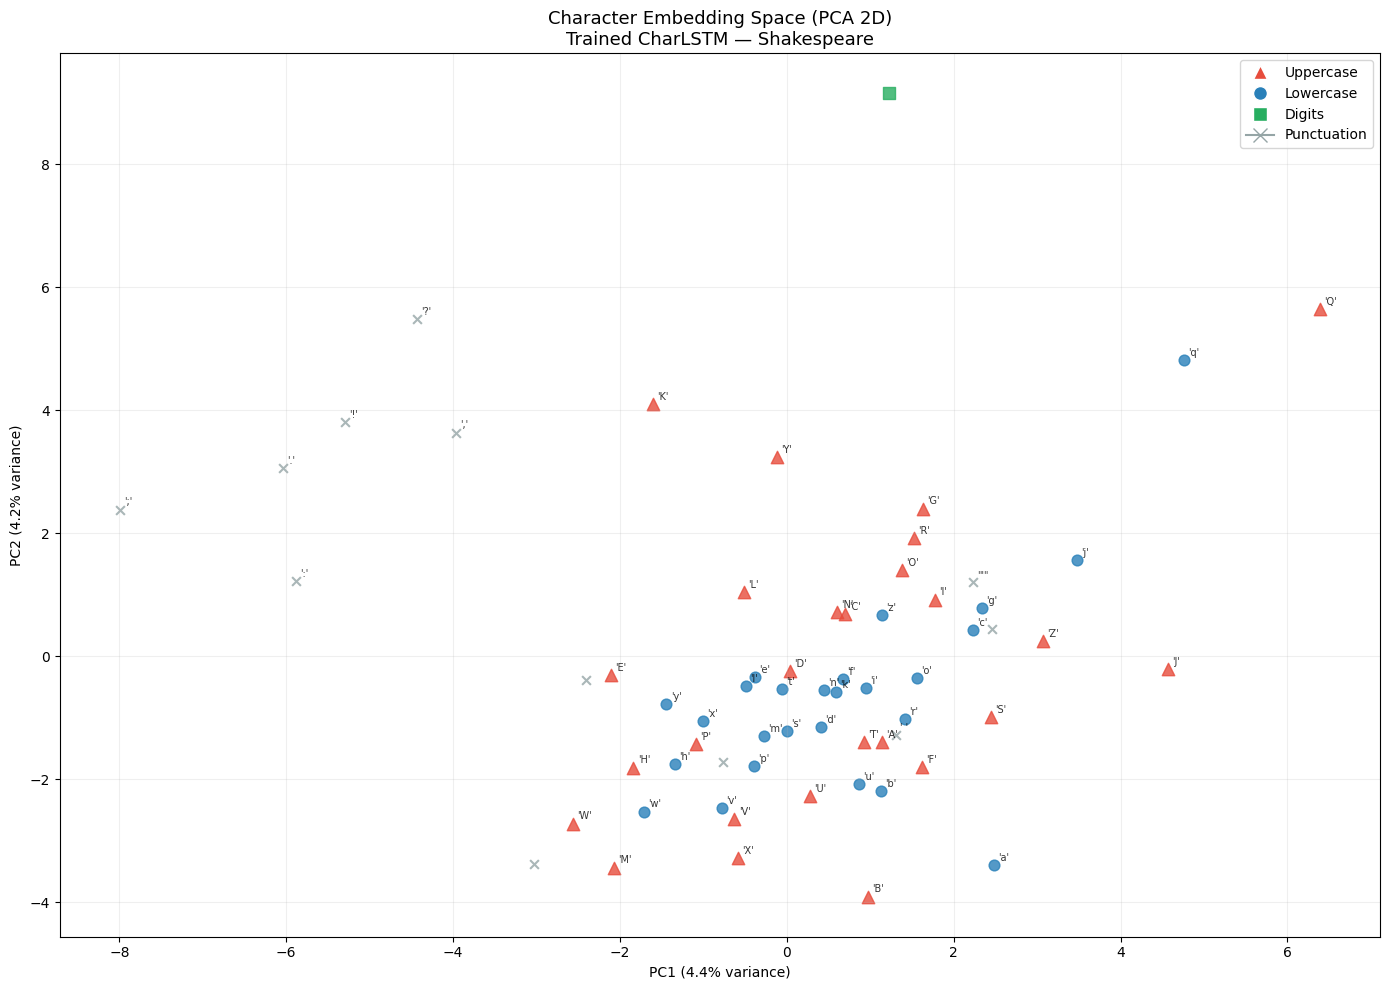

If the model learned well, uppercase letters cluster together,
lowercase cluster together, and punctuation forms its own group.


In [13]:
from sklearn.decomposition import PCA

model.eval()
with torch.no_grad():
    all_indices = torch.arange(vocab_size, dtype=torch.long).to(device)
    embeddings  = model.embedding(all_indices).cpu().numpy()

pca    = PCA(n_components=2)
emb_2d = pca.fit_transform(embeddings)

print(f'Embeddings shape    : {embeddings.shape}')
print(f'Variance explained  : {pca.explained_variance_ratio_.sum()*100:.1f}%')

plt.figure(figsize=(14, 10))
for idx, ch in idx2char.items():
    x, y = emb_2d[idx]
    if ch.isupper():
        color, marker, size = '#e74c3c', '^', 80
    elif ch.islower():
        color, marker, size = '#2980b9', 'o', 60
    elif ch.isdigit():
        color, marker, size = '#27ae60', 's', 80
    else:
        color, marker, size = '#95a5a6', 'x', 40

    plt.scatter(x, y, c=color, marker=marker, s=size, alpha=0.8)
    if ch.isalpha() or ch in '.,!?;:\'" ':
        plt.annotate(repr(ch), (x, y), fontsize=7, alpha=0.8,
                     xytext=(3, 3), textcoords='offset points')

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='^', color='w', markerfacecolor='#e74c3c', markersize=10, label='Uppercase'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#2980b9', markersize=10, label='Lowercase'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor='#27ae60', markersize=10, label='Digits'),
    Line2D([0],[0], marker='x', color='#95a5a6', markersize=10, label='Punctuation'),
]
plt.legend(handles=legend_elements, fontsize=10)
plt.title('Character Embedding Space (PCA 2D)\nTrained CharLSTM — Shakespeare', fontsize=13)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("If the model learned well, uppercase letters cluster together,")
print("lowercase cluster together, and punctuation forms its own group.")


# ============================================================
# Comments / Explanation
# ============================================================

# from sklearn.decomposition import PCA
# -------------------------------------
# Imports PCA (Principal Component Analysis) from scikit-learn.
#
# PCA is a dimensionality reduction technique.
#
# It transforms high-dimensional data into a lower-dimensional
# representation while preserving as much information (variance)
# as possible.
#
# Here, it is used to visualize learned character embeddings.

# model.eval()
# ------------
# Switches the model to evaluation mode.
#
# This disables Dropout and any other training-specific behavior,
# ensuring consistent embeddings.

# with torch.no_grad()
# --------------------
# Disables gradient computation.
#
# Since we are only extracting embeddings (not training),
# gradients are unnecessary.
#
# Benefits:
# - Faster execution.
# - Lower memory usage.

# torch.arange(vocab_size)
# ------------------------
# Creates a tensor containing every character index.
#
# Example:
#
# If:
# vocab_size = 65
#
# Output:
#
# [0, 1, 2, ..., 64]
#
# This allows us to retrieve the embedding vector
# for every character.

# dtype=torch.long
# ----------------
# Stores the indices as integers.
#
# Embedding layers require integer indices.

# .to(device)
# -----------
# Moves the tensor to the selected device
# (CPU or GPU).

# model.embedding(all_indices)
# ----------------------------
# Passes every character index through the Embedding layer.
#
# Instead of generating predictions,
# we directly retrieve the learned embedding vectors.
#
# Example:
#
# Character Index
#        │
#        ▼
# Embedding Layer
#        │
#        ▼
# Dense Vector

# .cpu()
# ------
# Moves the embeddings from GPU memory
# back to CPU memory.
#
# NumPy can only work with CPU tensors.

# .numpy()
# --------
# Converts the PyTorch tensor into a NumPy array.

# embeddings
# ----------
# Stores the embedding vector for every character.
#
# Shape:
#
# (Vocabulary Size,
#  Embedding Dimension)

# PCA(n_components=2)
# -------------------
# Creates a PCA object that will reduce the embeddings
# from many dimensions down to only two.
#
# Example:
#
# Original:
# 128 dimensions
#
# After PCA:
# 2 dimensions

# Why reduce to 2 dimensions?
# ---------------------------
# Humans cannot visualize 128-dimensional space.
#
# By reducing to two dimensions,
# the embeddings can be displayed on a scatter plot.

# pca.fit_transform(...)
# ---------------------
# Performs two steps:
#
# 1. Learns the principal components.
# 2. Projects the embeddings into the new
#    two-dimensional space.
#
# The resulting coordinates are stored in emb_2d.

# explained_variance_ratio_
# -------------------------
# Indicates how much information each principal
# component preserves.
#
# Example:
#
# PC1 = 42%
# PC2 = 21%
#
# Together:
#
# 63%
#
# This means the 2D visualization preserves
# approximately 63% of the original information.

# emb_2d
# ------
# Contains the new 2D coordinates for every character.
#
# Shape:
#
# (Vocabulary Size, 2)

# ------------------------------------------------------------
# The remaining code creates the visualization.
# (Graph-related code intentionally not explained.)
# ------------------------------------------------------------

# idx2char.items()
# ----------------
# Iterates through every character index and its
# corresponding character.
#
# Example:
#
# 0 → ' '
# 1 → '!'
# 2 → '"'
# ...

# ch.isupper()
# ------------
# Returns True if the character is an uppercase letter.

# ch.islower()
# ------------
# Returns True if the character is a lowercase letter.

# ch.isdigit()
# ------------
# Returns True if the character is a digit.

# ch.isalpha()
# ------------
# Returns True if the character is an alphabetic letter
# (either uppercase or lowercase).

# repr(ch)
# --------
# Returns the printable representation of a character.
#
# Useful for displaying invisible characters such as:
#
# ' '
# '\n'

# Line2D
# ------
# Used to create custom legend entries for the plot.
#
# It allows different marker styles to appear in
# the legend even though they were drawn separately.

# pca.explained_variance_ratio_[0]
# --------------------------------
# Returns the percentage of variance explained
# by the first principal component (PC1).

# pca.explained_variance_ratio_[1]
# --------------------------------
# Returns the percentage of variance explained
# by the second principal component (PC2).

# Why visualize embeddings?
# -------------------------
# During training, the Embedding layer learns numerical
# representations of characters.
#
# Characters with similar usage patterns tend to obtain
# similar embedding vectors.
#
# For example:
#
# Uppercase letters
#       │
#       ▼
# Similar Embeddings
#
# Lowercase letters
#       │
#       ▼
# Similar Embeddings
#
# Punctuation
#       │
#       ▼
# Another Region

# What does PCA help us observe?
# ------------------------------
# PCA allows us to inspect whether the neural network
# has learned meaningful relationships between characters.
#
# If training was successful, similar characters often
# appear close together in the reduced 2D space.

# Overall Purpose of This Cell
# ----------------------------
# This cell extracts the learned character embeddings,
# reduces them from high-dimensional space to two dimensions
# using PCA, and visualizes how the model internally
# represents different characters.
#
# Well-trained embeddings often reveal clusters of
# semantically or functionally similar characters,
# demonstrating that the neural network has learned
# useful representations beyond simple integer encoding.
# ============================================================

In [14]:
final_loss        = np.mean(train_losses[-100:])
final_perplexity  = np.exp(final_loss)
initial_perplexity= np.exp(train_losses[0])

print("=" * 60)
print("       EXPERIMENT 3 — FINAL SUMMARY")
print("=" * 60)
print(f"Dataset            : Shakespeare (~1M characters)")
print(f"Vocabulary size    : {vocab_size} unique characters")
print(f"Model              : Character-level LSTM")
print(f"Architecture       : Embedding({vocab_size},{EMBED_DIM}) → "
      f"LSTM({HIDDEN_SIZE}, {NUM_LAYERS} layers) → Linear({vocab_size})")
print(f"Parameters         : {sum(p.numel() for p in model.parameters()):,}")
print()
print(f"Training Iterations: {NUM_ITERATIONS}")
print(f"Batch Size         : {BATCH_SIZE}")
print(f"Sequence Length    : {SEQ_LENGTH}")
print(f"Optimizer          : Adam  (lr=3e-3 with ReduceLROnPlateau)")
print(f"Gradient Clipping  : max_norm=1.0")
print()
print(f"Results:")
print(f"  Starting Perplexity : {initial_perplexity:.1f}  (random = {vocab_size})")
print(f"  Final   Perplexity  : {final_perplexity:.1f}")
print(f"  Final   Loss        : {final_loss:.4f}")
print()
print(f"Key Concepts Demonstrated:")
print(f"  ✓ Character tokenization and vocabulary building")
print(f"  ✓ Embedding layer — learned character representations")
print(f"  ✓ LSTM hidden state — memory across the sequence")
print(f"  ✓ Gradient clipping — essential for stable RNN training")
print(f"  ✓ Temperature sampling — controlling generation creativity")
print(f"  ✓ Perplexity — proper evaluation metric for language models")
print(f"  ✓ PCA visualization of learned embedding space")
print("=" * 60)


# ============================================================
# Comments / Explanation
# ============================================================

# np.mean(train_losses[-100:])
# ----------------------------
# Computes the average loss over the final 100 training iterations.
#
# Using an average provides a more reliable estimate than
# using the loss from only the final iteration because
# individual batches can cause small fluctuations.

# train_losses[-100:]
# -------------------
# Selects the last 100 recorded loss values.
#
# Negative indexing starts counting from the end of the list.

# final_loss
# ----------
# Represents the model's average Cross Entropy Loss
# near the end of training.

# np.exp(final_loss)
# ------------------
# Converts the final Cross Entropy Loss into Perplexity.
#
# Formula:
#
# Perplexity = e^(Loss)
#
# Lower perplexity indicates a better language model.

# final_perplexity
# ----------------
# Measures how well the trained model predicts
# the next character after training.

# np.exp(train_losses[0])
# -----------------------
# Converts the very first recorded loss into Perplexity.
#
# This represents the model's performance at the beginning
# of training before it had learned meaningful patterns.

# initial_perplexity
# ------------------
# Serves as a baseline for comparison.
#
# Comparing the initial and final perplexity clearly shows
# how much the model improved during training.

# sum(p.numel() for p in model.parameters())
# ------------------------------------------
# Computes the total number of trainable parameters
# in the neural network.
#
# model.parameters()
# returns every trainable weight and bias.
#
# p.numel()
# returns the number of elements inside each parameter tensor.
#
# sum(...)
# adds them together to obtain the total parameter count.

# Why report the final average loss?
# ----------------------------------
# Training loss naturally fluctuates because every batch
# contains different randomly selected sequences.
#
# Averaging over multiple iterations provides a much more
# stable measure of the model's final performance.

# Why compare starting and final perplexity?
# ------------------------------------------
# The starting perplexity reflects the performance of an
# almost untrained model.
#
# The final perplexity reflects how well the trained model
# predicts the next character.
#
# A significant decrease demonstrates successful learning.

# What does the final summary tell us?
# -----------------------------------
# This summary provides a concise overview of:
#
# - The dataset used.
# - Vocabulary size.
# - Neural network architecture.
# - Total trainable parameters.
# - Training hyperparameters.
# - Final evaluation metrics.
# - Core deep learning concepts demonstrated.

# Overall Purpose of This Cell
# ----------------------------
# This cell summarizes the entire experiment by presenting
# the model configuration, training settings, and evaluation
# metrics in one place.
#
# It provides a convenient overview of the experiment's
# outcome and highlights the key concepts learned during
# the implementation of a character-level LSTM language model.
# ============================================================

       EXPERIMENT 3 — FINAL SUMMARY
Dataset            : Shakespeare (~1M characters)
Vocabulary size    : 65 unique characters
Model              : Character-level LSTM
Architecture       : Embedding(65,128) → LSTM(512, 2 layers) → Linear(65)
Parameters         : 3,457,729

Training Iterations: 3000
Batch Size         : 64
Sequence Length    : 100
Optimizer          : Adam  (lr=3e-3 with ReduceLROnPlateau)
Gradient Clipping  : max_norm=1.0

Results:
  Starting Perplexity : 64.8  (random = 65)
  Final   Perplexity  : 3.4
  Final   Loss        : 1.2286

Key Concepts Demonstrated:
  ✓ Character tokenization and vocabulary building
  ✓ Embedding layer — learned character representations
  ✓ LSTM hidden state — memory across the sequence
  ✓ Gradient clipping — essential for stable RNN training
  ✓ Temperature sampling — controlling generation creativity
  ✓ Perplexity — proper evaluation metric for language models
  ✓ PCA visualization of learned embedding space
